# K-Nearest Neighbors: Learning by Looking Around

**DCS 404 · Data Science and Machine Learning**

---

Every model in this course so far has *trained*. Linear and logistic regression ran gradient descent until
their coefficients settled; decision trees grew and pruned themselves into shape. Training distilled the
dataset into a compact artifact — a handful of weights, a flowchart — and then the data itself could be
thrown away.

Today's algorithm refuses to distill. **K-Nearest Neighbors (KNN)** just *keeps the entire training set*,
and when a new sample arrives, it answers by analogy: *find the $K$ stored examples most similar to this
one, and let them vote* (or, for regression, average them). That's the whole algorithm. No cost function,
no gradients, no coefficients — the "model" *is* the memorized data.

This makes KNN the simplest serious algorithm in machine learning, and also the most honest mirror of a
deep assumption we've been making all along: **similar inputs have similar outputs**. KNN bets everything
on that one idea. In exchange, it surfaces questions the other models let us dodge: what exactly does
*similar* mean (distance metrics)? How many neighbors should vote ($K$ — our old friend, the bias-variance
dial, in its purest form)? And what happens to "nearness" itself when features live on wild scales, or when
there are hundreds of dimensions? By the end, you'll also see why the *prediction* — free for every earlier
model — is the expensive step here, and how clever data structures (KD-trees, ball trees) rescue it.

## How to work through this

The usual rhythm: run every code cell (`Shift + Enter`), study the output, *then* read the commentary.
Cells build on each other, so if something errors, run from the top.

The module is in three acts:

1. **Sections 1–4** build the algorithm: instance-based learning, distance metrics (the post office
   problem), the voting scheme, and a from-scratch implementation checked against scikit-learn.
2. **Sections 5–7** are the practical hazards: choosing $K$ (bias-variance again), the scale trap that
   silently breaks distance, and the curse of dimensionality.
3. **Sections 8–10** finish the story: KNN for regression (with a surprise win over linear regression),
   how KD-trees and ball trees make neighbor search fast, and an honest pros/cons verdict.

Old friends return throughout: iris, the diabetes data, the Advertising data, and the noisy sine wave.

## Learning objectives

After completing this module you will be able to:

- Contrast **model-based** and **instance-based (lazy) learning**, and place KNN in the second family.
- State the properties of a **distance metric** and compute **Euclidean**, **Manhattan**, and general
  **Minkowski** distances.
- Implement a KNN classifier **from scratch** with numpy, and use scikit-learn's `KNeighborsClassifier` /
  `KNeighborsRegressor`.
- Explain the effect of $K$ on the decision boundary in **bias-variance** terms, and choose $K$ with a
  validation sweep; describe **distance-weighted** voting.
- Demonstrate why **feature scaling is mandatory** for KNN, and what noisy/irrelevant features (the
  **curse of dimensionality**) do to it.
- Use KNN for **regression**, describe its step-shaped fit and its inability to extrapolate.
- Sketch how **KD-trees** and **ball trees** accelerate nearest-neighbor search, and list KNN's practical
  pros and cons.

## Setup

Run this once. Libraries, plotting style, and the two returning datasets (diabetes and Advertising).

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris, load_wine, make_classification
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.metrics import accuracy_score, classification_report, mean_absolute_error, r2_score

# A consistent look for every plot in this notebook
plt.rcParams.update({
    "figure.figsize": (7, 4.5),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
sns.set_palette("deep")
RANDOM_STATE = 42

def load_csv(name, **kwargs):
    for candidate in [Path(f"data/{name}"), Path(f"notebooks/data/{name}")]:
        if candidate.exists():
            print(f"Loaded {name} from: {candidate}")
            return pd.read_csv(candidate, **kwargs)
    raise FileNotFoundError(f"Could not find {name}. Expected it in a data/ folder next to the notebook.")

diabetes = load_csv("diabetes.csv")
ads = load_csv("Advertising.csv", index_col=0)

Loaded diabetes.csv from: data/diabetes.csv
Loaded Advertising.csv from: data/Advertising.csv


---
## 1. Two ways to generalize

Think about how *people* handle a new situation. Sometimes we apply a rule we've internalized
("red sky at night, sailor's delight"). Sometimes we just recall similar past cases ("the last two times a
restaurant looked like this, the food was great"). Machine learning has both temperaments:

- **Model-based learning** — everything so far in this course. Training data goes in, a *parameterized
  hypothesis* $h(x)$ comes out (coefficients, tree splits), and the data can be discarded. Training is
  slow and thoughtful; prediction is instant — plug into the formula.

- **Instance-based learning** (also *lazy learning* or *memory-based learning*) — the system **stores the
  training examples themselves** and postpones all work to prediction time. When a query arrives, it
  hunts through memory for *similar* stored examples and derives the answer from them, leaning entirely on
  one assumption: **similar inputs have similar targets**.

<div align="center">
<img src="resources/images/knn_instance_learning.gif" width="560">

*Figure 1 — Instance-based learning: store everything, answer new queries by consulting the most similar
stored examples.*
</div>

The trade flips every cost we're used to: "training" is instant (it's just storage), but *prediction*
requires touching the whole dataset, and the model's memory footprint is the dataset. The hypothesis also
grows with the data — more examples means a finer-grained answer machine, with no fixed formula anywhere.

### From rote learning to neighbors

The crudest instance-based learner is **rote learning**: answer only if the new sample *exactly matches* a
stored one. Consider a tiny dataset for predicting whether a restaurant is worth queueing for:

| Id | Food quality | Ambience | Hygiene | Service | Worth the queue? |
|---|---|---|---|---|---|
| 1 | good | classy | clean | fast | **yes** |
| 2 | good | casual | clean | fast | **yes** |
| 3 | bad | casual | dirty | slow | **no** |
| 4 | good | classy | dirty | slow | **no** |
| 5 | good | casual | clean | slow | **yes** |
| 6 | bad | classy | clean | fast | **no** |

A new restaurant — (good, classy, clean, **slow**) — has no exact match in the table, so rote learning
simply shrugs. That's a hopeless failure mode: exact matches almost never happen in real, continuous data.

The fix is to relax "identical" into "**closest**": find the stored example *most similar* to the query and
copy its label — the **nearest neighbor (1-NN)** rule. Our new restaurant's closest match is Id 5 (three of
four features agree), which says **yes**. And once "closest" is doing all the work, one question becomes
urgent — what exactly does *close* mean?

---
## 2. Distance: the heart of the algorithm

### The post office problem

You're standing at position (12, 9) in a city and need to mail a letter. Seven post offices are scattered
around you:

<div align="center">
<img src="resources/images/knn_post_office.png" width="560">

*Figure 2 — The post office problem: which one is "nearest"?*
</div>

The question is unanswerable until you define **distance** — and that definition is a genuine choice, not
a given. Formally, a function $d(x, y)$ is a **distance metric** if for all points $x, y, z$:

1. **Non-negativity:** $d(x,y) \geq 0$ — distances are never negative.
2. **Identity:** $d(x,y) = 0 \iff x = y$ — zero distance means the same point.
3. **Symmetry:** $d(x,y) = d(y,x)$ — the trip there equals the trip back.
4. **Triangle inequality:** $d(x,z) \leq d(x,y) + d(y,z)$ — detours never help.

Many functions satisfy these; three matter most for us.

### Euclidean distance — as the crow flies

The straight-line distance, Pythagoras in $n$ dimensions:

$$d(x, y) = \sqrt{\sum_{i=1}^{n} (x_i - y_i)^2}$$

<div align="center">
<img src="resources/images/knn_euclidean.png" width="440">

*Figure 3 — Euclidean distance: the hypotenuse.*
</div>

### Manhattan distance — as the taxi drives

In a gridded city you can't cut through buildings; you travel along the blocks. Sum the absolute
differences per coordinate:

$$d(x, y) = \sum_{i=1}^{n} |x_i - y_i|$$

<div align="center">
<img src="resources/images/knn_manhattan.png" width="440">

*Figure 4 — Manhattan (taxicab) distance: along the grid, never through it.*
</div>

### Minkowski distance — both of the above, one dial

$$d(x, y) = \left( \sum_{i=1}^{n} |x_i - y_i|^p \right)^{1/p}$$

Set $p = 1$ and you get Manhattan; $p = 2$, Euclidean. Scikit-learn's KNN exposes exactly this dial (the
`p` parameter, default 2). Larger $p$ weights the biggest single-coordinate gap ever more heavily.

*(One more worth knowing by name: **Mahalanobis distance**, which measures distance from a point to a
distribution — it rescales and de-correlates the features using their covariance matrix before applying
Euclidean distance. It's the principled fix when features are correlated; we'll meet its cheaper cousin,
plain standardization, in Section 6.)*

### Solving the post office problem

In a real city we travel by blocks, so Manhattan distance is the honest metric here. The **brute-force**
solution: measure the distance to *every* candidate, take the minimum —

In [2]:
post_offices = np.array([(6, 12), (3, 7), (10, 10), (8, 4), (15, 2), (12, 11), (14, 10)])
you = np.array([12, 9])

manhattan_distances = np.abs(post_offices - you).sum(axis=1)

for (ox, oy), dist in zip(post_offices, manhattan_distances):
    print(f"Post office ({ox}, {oy}): {dist} blocks")

nx, ny = post_offices[manhattan_distances.argmin()]
print(f"\n→ Nearest post office: ({nx}, {ny}), {manhattan_distances.min()} blocks away")

Post office (6, 12): 9 blocks
Post office (3, 7): 11 blocks
Post office (10, 10): 3 blocks
Post office (8, 4): 9 blocks
Post office (15, 2): 10 blocks
Post office (12, 11): 2 blocks
Post office (14, 10): 3 blocks

→ Nearest post office: (12, 11), 2 blocks away


Post office (12, 11) wins at 2 blocks. Note what the computation cost: one distance per stored point —
$O(n \cdot d)$ for $n$ points in $d$ dimensions, *every time you ask*. Seven post offices, trivial; seven
million products in a recommender system, a real problem. Pin that thought for Section 9.

---
## 3. The K-NN algorithm

One nearest neighbor is a fragile advisor — if the single closest stored example happens to be an outlier
or mislabelled, the prediction is garbage. The obvious remedy is the one we use when buying a house: don't
price it off *one* neighboring sale, consult the whole **neighborhood**. That's the "K" in KNN:

**Hyperparameters** (chosen before anything runs): the number of neighbors $K$ and the distance metric $d$.

**Training phase:** store the training set $D = \{(x_i, y_i)\}_{i=1}^{n}$. That's all.

**Prediction phase**, for a query $x_t$:
1. Compute $d(x_t, x_i)$ for every stored example.
2. Take the $K$ examples with the smallest distances — the *neighborhood*.
3. **Classification:** predict the **majority vote** of the neighborhood's labels.
   **Regression:** predict the **average** (we'll get there in Section 8).

<div align="center">
<img src="resources/images/knn_voting.gif" width="560">

*Figure 5 — KNN classification: the query point polls its $K$ closest neighbors and takes the majority.*
</div>

Try it on the restaurant table with $K = 3$: our query (good, classy, clean, slow) has neighbors Id 5
(3 features shared, **yes**), Id 1 (3 shared, **yes**), and Id 4 (2 shared, **no**) — the vote is 2–1,
prediction **yes**. Notice how the lone "no" got outvoted: that's exactly the robustness 1-NN lacked.

*(A tie-breaking practicality: for binary problems, choose an odd $K$ so the vote can't split evenly.)*

---
## 4. K-NN from scratch

An algorithm this simple deserves to be built by hand — the entire classifier is a dozen lines of numpy.
Distance, sort, vote:

In [3]:
def knn_predict_one(X_train, y_train, x_new, k):
    """Classify a single sample by majority vote of its k nearest neighbors."""
    distances = np.sqrt(((X_train - x_new) ** 2).sum(axis=1))   # Euclidean to every stored point
    nearest = np.argsort(distances)[:k]                          # indices of the k closest
    votes = y_train[nearest]                                     # their labels
    return np.bincount(votes).argmax()                           # majority vote

def knn_classifier(X_train, y_train, X_new, k):
    """Classify every row of X_new."""
    return np.array([knn_predict_one(X_train, y_train, x, k) for x in X_new])

Note there is no `fit` worth writing — "training" is the act of keeping `X_train` and `y_train` around.
All the work lives in prediction, and its cost is visible in the code: for each query, a distance to *all*
$n$ stored points ($O(n \cdot d)$), plus the sort. Brute-force KNN prediction costs roughly
$O(k \, n \, d)$ per batch of queries.

Let's test it on iris (150 flowers, 4 measurements, 3 species) against scikit-learn's
`KNeighborsClassifier`:

In [4]:
iris = load_iris()
X_ir_train, X_ir_test, y_ir_train, y_ir_test = train_test_split(
    iris.data, iris.target, test_size=0.3, random_state=RANDOM_STATE, stratify=iris.target)

# Ours
y_pred_scratch = knn_classifier(X_ir_train, y_ir_train, X_ir_test, k=5)

# Scikit-learn's
sk_knn = KNeighborsClassifier(n_neighbors=5)
sk_knn.fit(X_ir_train, y_ir_train)
y_pred_sklearn = sk_knn.predict(X_ir_test)

print(f"From-scratch accuracy: {accuracy_score(y_ir_test, y_pred_scratch):.4f}")
print(f"Scikit-learn accuracy: {accuracy_score(y_ir_test, y_pred_sklearn):.4f}")
print(f"Predictions identical: {np.array_equal(y_pred_scratch, y_pred_sklearn)}")

From-scratch accuracy: 0.9778
Scikit-learn accuracy: 0.9778
Predictions identical: True


Identical predictions, ≈96% accuracy, and the entire algorithm fits on an index card. From here on we'll
use scikit-learn's version — same logic, but with the fast search structures of Section 9 built in.

---
## 5. K is the bias-variance dial

$K$ is KNN's *only* real knob, and it is the purest form of the complexity dial we've been turning all
course (polynomial degree, tree depth…). Let's watch it work.

### K = 1: trust one witness

With $K=1$, space is carved into one cell per training point — every location is claimed by whichever
training point is closest. The resulting mosaic is called a **Voronoi diagram**, and its boundaries are the
potential decision boundaries of 1-NN:

<div align="center">
<img src="resources/images/knn_voronoi.png" width="520">

*Figure 6 — The Voronoi view of 1-NN: each training point rules its own cell, outliers included.*
</div>

Every training point is perfectly classified — including the mislabelled and the freakish. Sound familiar?
$K=1$ is KNN's version of the fully grown decision tree: **zero bias, maximal variance**, private fences
around every noisy point.

### Turning the dial

Let's see the whole range live, on a noisy 3-class dataset:

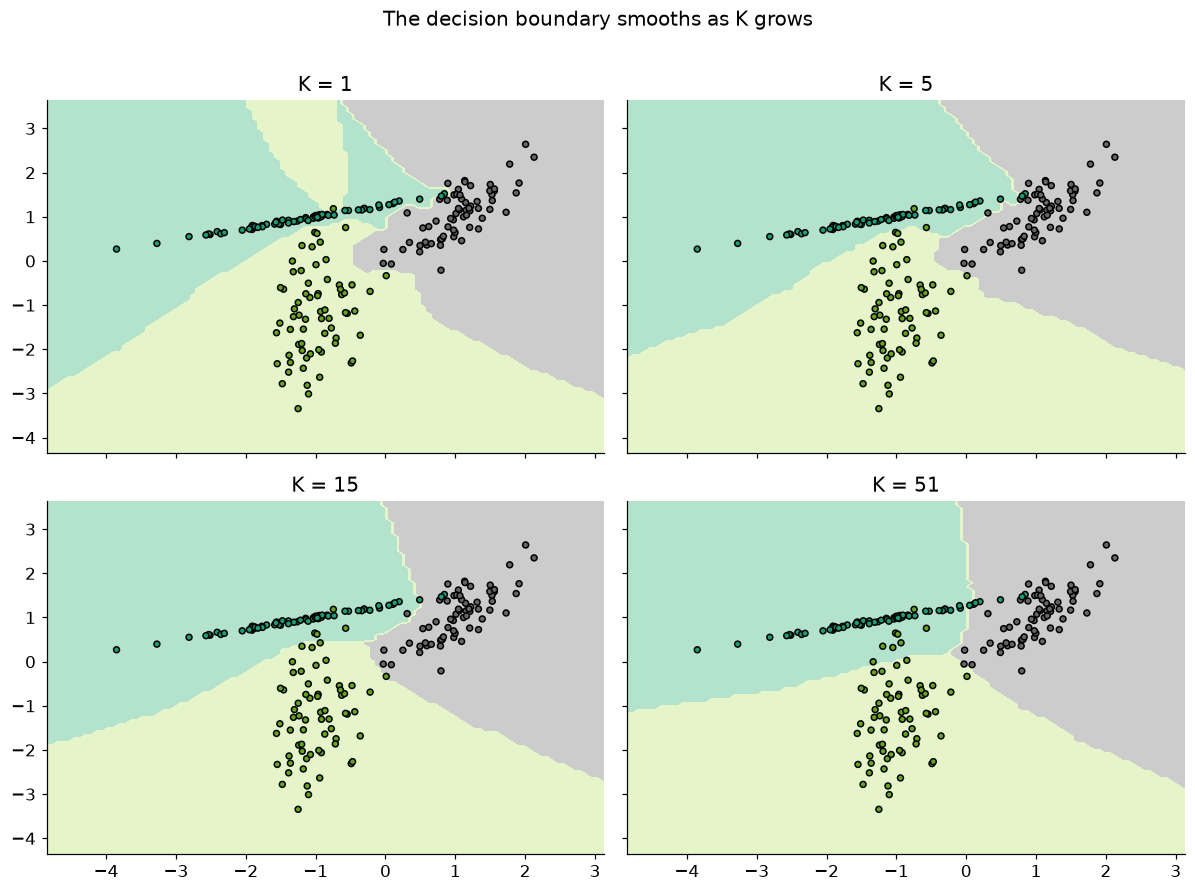

In [5]:
X_syn, y_syn = make_classification(
    n_samples=200, n_features=2, n_informative=2, n_redundant=0, n_repeated=0,
    n_classes=3, n_clusters_per_class=1, class_sep=1.0, random_state=10)

fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True, sharey=True)

for ax, k in zip(axes.ravel(), [1, 5, 15, 51]):
    clf = KNeighborsClassifier(n_neighbors=k).fit(X_syn, y_syn)
    DecisionBoundaryDisplay.from_estimator(clf, X_syn, response_method="predict",
                                           multiclass_colors="Pastel2", ax=ax)
    ax.scatter(X_syn[:, 0], X_syn[:, 1], c=y_syn, cmap="Dark2", edgecolor="black", s=15)
    ax.set_title(f"K = {k}")
    ax.grid(False)

fig.suptitle("The decision boundary smooths as K grows", y=1.01)
plt.tight_layout()
plt.show()

Read the four panels as a story:

- **K = 1:** jagged coastlines and tiny islands — one enclave per noisy point. Overfitting, drawn as a map.
- **K = 5, 15:** the islands dissolve; boundaries follow the genuine class structure.
- **K = 51:** so smooth it starts ignoring real detail — with $K$ approaching the dataset size, every
  prediction drifts toward the *global* majority class. Underfitting.

Small $K$ → **high variance, low bias** (decisions hang on one or two possibly-noisy points). Large $K$ →
**low variance, high bias** (decisions average over so many neighbors that local structure is smoothed
away). The sweet spot lives in between, and — as with every hyperparameter in this course — we find it by
sweeping held-out accuracy. On the diabetes data (standardized; Section 6 explains why):

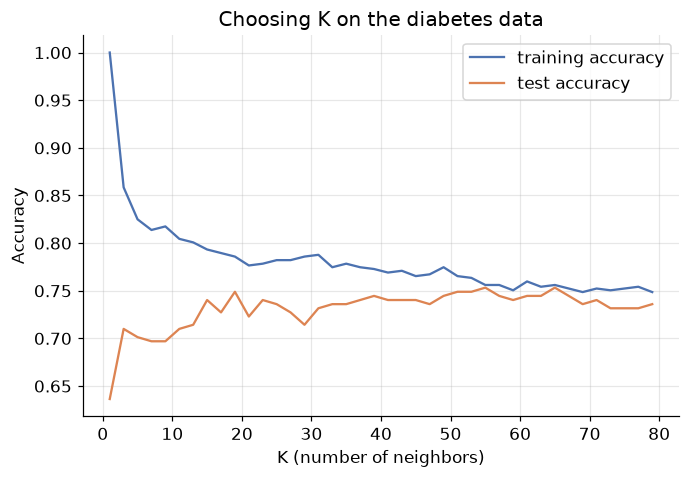

K=1:  train 100.0%, test 63.6%   ← memorization
Best test accuracy 75.3% at K = 55


In [6]:
X_diab = diabetes.drop("Outcome", axis=1)
y_diab = diabetes["Outcome"]
Xd_train, Xd_test, yd_train, yd_test = train_test_split(
    X_diab, y_diab, test_size=0.3, random_state=RANDOM_STATE)

k_values = range(1, 80, 2)                       # odd values: no tied votes
train_acc, test_acc = [], []
for k in k_values:
    model = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k))
    model.fit(Xd_train, yd_train)
    train_acc.append(model.score(Xd_train, yd_train))
    test_acc.append(model.score(Xd_test, yd_test))

plt.plot(k_values, train_acc, label="training accuracy")
plt.plot(k_values, test_acc, label="test accuracy")
plt.xlabel("K (number of neighbors)")
plt.ylabel("Accuracy")
plt.title("Choosing K on the diabetes data")
plt.legend()
plt.show()

best_k = list(k_values)[int(np.argmax(test_acc))]
print(f"K=1:  train {train_acc[0]:.1%}, test {test_acc[0]:.1%}   ← memorization")
print(f"Best test accuracy {max(test_acc):.1%} at K = {best_k}")

The signature curve of the whole course, one more time: at $K=1$ training accuracy is a perfect 100%
(every point is its own nearest neighbor!) while test accuracy is the *worst on the chart*; test accuracy
then climbs to a plateau in the middle $K$ range and sags as $K$ grows toward underfitting. In production
you'd pick $K$ by cross-validation rather than a single test split — but the shape of the decision is
exactly this.

### Weighted voting: neighbors aren't all equal

Plain KNN gives every neighborhood member one vote, whether it's a hair's breadth away or at the far edge
of the neighborhood. **Distance-weighted KNN** weights each vote by $1/d$ — closer neighbors speak louder.
Scikit-learn: `weights="distance"` (default `"uniform"`).

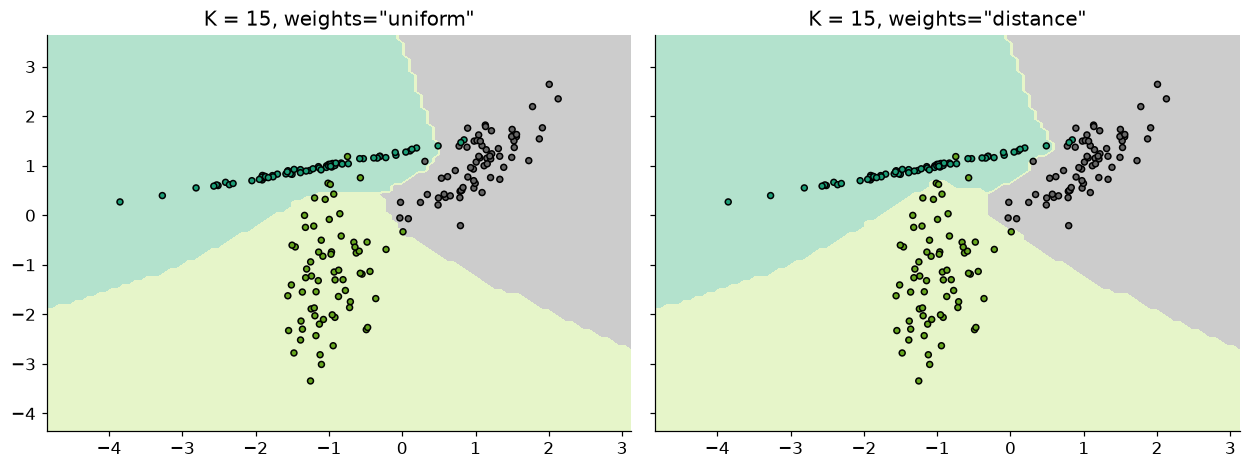

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4), sharex=True, sharey=True)

for ax, w in zip(axes, ["uniform", "distance"]):
    clf = KNeighborsClassifier(n_neighbors=15, weights=w).fit(X_syn, y_syn)
    DecisionBoundaryDisplay.from_estimator(clf, X_syn, response_method="predict",
                                           multiclass_colors="Pastel2", ax=ax)
    ax.scatter(X_syn[:, 0], X_syn[:, 1], c=y_syn, cmap="Dark2", edgecolor="black", s=15)
    ax.set_title(f'K = 15, weights="{w}"')
    ax.grid(False)

plt.tight_layout()
plt.show()

Weighting sharpens the boundary near dense regions (a very close neighbor can outvote several distant
ones) while keeping the noise-resistance of a large $K$. It also quietly solves vote ties. The cost: the
model bends further toward individual training points — a little variance bought back. Treat
`weights` as a second, smaller hyperparameter to validate alongside $K$.

---
## 6. The scale trap

Here is KNN's most dangerous failure mode, and it makes *no error message*. Distance treats every feature's
units at face value. Consider house data:

| Area (sq. ft.) | Price (K) |
|---|---|
| 2424 | 162000 |
| 960 | 1265 |
| 840 | 89450 |

A difference of 1,000 in *price* and 1,000 in *area* contribute identically to Euclidean distance — yet
1,000 sq. ft. is a mansion-sized difference while ₹1,000 in price is a rounding error. **Whichever feature
has the biggest numbers owns the distance**, and the others might as well not exist.

Watch it happen on the classic wine dataset (13 chemical measurements, 3 grape cultivars). One feature —
`proline` — ranges in the hundreds-to-thousands while most others live between 0 and 5:

In [8]:
wine = load_wine()
Xw_train, Xw_test, yw_train, yw_test = train_test_split(
    wine.data, wine.target, test_size=0.3, random_state=RANDOM_STATE, stratify=wine.target)

# Feature ranges: spot the bully
ranges = pd.DataFrame(wine.data, columns=wine.feature_names).agg(["min", "max"]).T
print(ranges.round(1).sort_values("max").tail(4))

knn_raw = KNeighborsClassifier(n_neighbors=5).fit(Xw_train, yw_train)
knn_scaled = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5)).fit(Xw_train, yw_train)

print(f"\nKNN on raw features:          {knn_raw.score(Xw_test, yw_test):.1%}")
print(f"KNN on standardized features: {knn_scaled.score(Xw_test, yw_test):.1%}")

                     min     max
alcohol             11.0    14.8
alcalinity_of_ash   10.6    30.0
magnesium           70.0   162.0
proline            278.0  1680.0

KNN on raw features:          72.2%
KNN on standardized features: 94.4%


**Twenty-two percentage points**, from one line of preprocessing. On the raw features, "nearest" secretly
meant "nearest in proline" — twelve of the thirteen measurements were being ignored. Standardization
(mean 0, variance 1 — the same `StandardScaler` from the Gradient Descent module) gives every feature an
equal voice, and the other twelve suddenly matter.

The rule is absolute: **KNN must never see unscaled features.** Contrast this with last module's decision
trees, which are scale-*invariant* (a threshold test doesn't care about units) — a reminder that
preprocessing needs differ per model family. And notice the pipeline detail: the scaler is *fitted on
training data only*, exactly as the ML Workflow module taught, so no test-set information leaks into the
distances.

*(Which features you feed KNN matters just as much as their scale — on iris, KNN with only the two sepal
measurements reaches ~82% test accuracy, the two petal measurements ~93%, all four ~98%. Distance can only
find structure in the features you give it. Exercise 2 has you verify this.)*

---
## 7. The curse of dimensionality

Scaling makes features equal — but what if some features simply *shouldn't* be there? Every irrelevant
feature adds a dimension of pure noise to the distance calculation, and distance degrades gracelessly:
in high-dimensional space, *everything becomes far from everything*, and the contrast between "nearest"
and "farthest" neighbor shrinks toward nothing. This is the **curse of dimensionality**, and KNN — whose
entire worldview is distance — suffers it worse than any model we've met.

The demonstration writes itself: take iris (four honest features, ~91% accuracy at $K=5$ on this split)
and progressively bury it in standardized random-noise features:

In [9]:
rng = np.random.default_rng(0)
results = []
for n_junk in [0, 5, 20, 50, 100]:
    Xtr = np.c_[X_ir_train, rng.normal(size=(len(X_ir_train), n_junk))]
    Xte = np.c_[X_ir_test, rng.normal(size=(len(X_ir_test), n_junk))]
    model = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5)).fit(Xtr, y_ir_train)
    results.append({"junk features": n_junk, "total dimensions": 4 + n_junk,
                    "test accuracy": model.score(Xte, y_ir_test)})

pd.DataFrame(results).set_index("junk features").round(3)

,total dimensions,test accuracy
junk features,,
0,4,0.911
5,9,0.844
20,24,0.778
50,54,0.711
100,104,0.556


Every batch of noise features drags accuracy down — with 100 of them, KNN has lost roughly a third of its
accuracy *without a single informative feature being touched*. The four real measurements are still in
there, pristine; they've simply been outvoted in the distance sum by a hundred coin-flips. (Note that
scaling can't save us here — the noise features are already standardized. Scale fixes *loud* features;
nothing in the distance fixes *meaningless* ones.)

Two practical morals:

- **KNN needs curated features.** Feature selection (recall the lasso's talent for it, from the
  Regularization module) or dimensionality reduction is often a prerequisite, not an optimization.
- **KNN prefers wide data short**: many samples, few dimensions. Hundreds of features with modest sample
  counts is decision-tree or regularized-linear territory.

---
## 8. K-NN regression

Swap one word in the algorithm — *vote* becomes *average* — and KNN does regression:

$$\hat{y}_t = \frac{1}{K} \sum_{x_i \in \text{neighborhood}(x_t)} y_i$$

Everything else (distance, $K$, scaling, the curse) carries over unchanged. Scikit-learn:
`KNeighborsRegressor`. Let's fit our old friend the noisy sine wave and look hard at the *shape* of what
KNN produces:

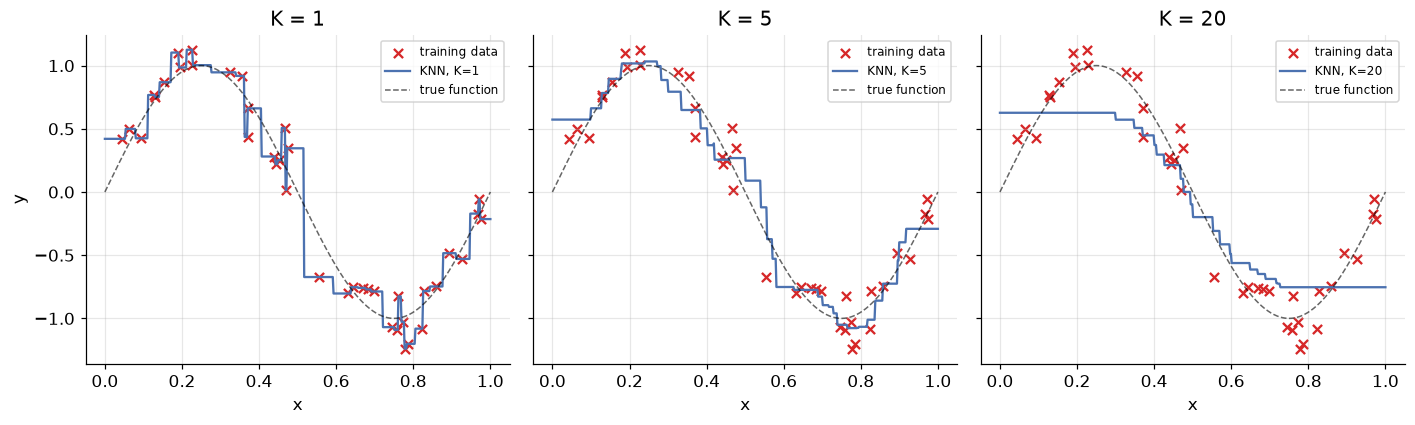

In [10]:
rng = np.random.default_rng(RANDOM_STATE)
x_sine = np.sort(rng.uniform(0, 1, 40)).reshape(-1, 1)
y_sine = np.sin(2 * np.pi * x_sine).ravel() + rng.normal(0, 0.2, 40)

x_grid = np.linspace(0, 1, 500).reshape(-1, 1)

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
for ax, k in zip(axes, [1, 5, 20]):
    knn_reg = KNeighborsRegressor(n_neighbors=k).fit(x_sine, y_sine)
    ax.scatter(x_sine, y_sine, color="tab:red", marker="x", label="training data")
    ax.plot(x_grid, knn_reg.predict(x_grid), label=f"KNN, K={k}")
    ax.plot(x_grid, np.sin(2 * np.pi * x_grid), "k--", linewidth=1, alpha=0.6, label="true function")
    ax.set_title(f"K = {k}")
    ax.set_xlabel("x")
    ax.legend(fontsize=8)
axes[0].set_ylabel("y")
plt.tight_layout()
plt.show()

Three observations, all characteristic of KNN regression:

- **The fit is a staircase.** Between two training points the neighborhood doesn't change, so neither does
  the prediction — the function is piecewise-constant, never smooth. (Compare the smooth polynomials of
  the Regression module.)
- **$K$ is the same dial as ever.** $K=1$ chases every noisy point (the staircase wiggles); $K=20$
  averages half the dataset and flattens the peaks it should preserve.
- **It never invented anything.** The prediction is always an average of *observed* $y$ values — which is
  robust, but has a sharp consequence at the edges:

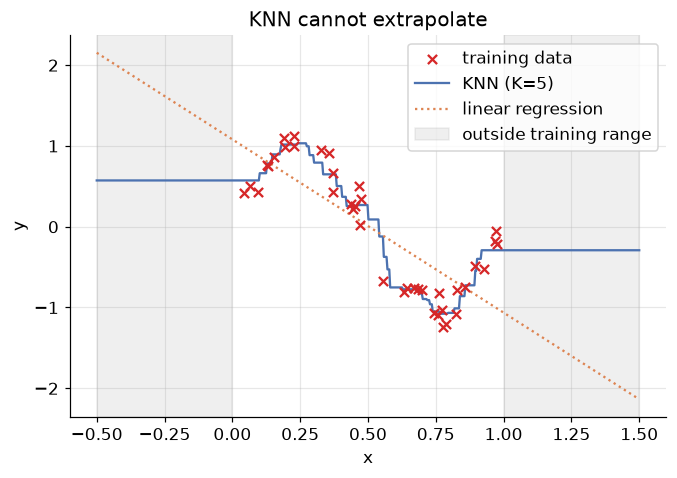

In [11]:
x_wide = np.linspace(-0.5, 1.5, 600).reshape(-1, 1)      # well beyond the training range [0, 1]

knn_reg = KNeighborsRegressor(n_neighbors=5).fit(x_sine, y_sine)
lin_reg = LinearRegression().fit(x_sine, y_sine)

plt.scatter(x_sine, y_sine, color="tab:red", marker="x", label="training data", zorder=3)
plt.plot(x_wide, knn_reg.predict(x_wide), label="KNN (K=5)")
plt.plot(x_wide, lin_reg.predict(x_wide), label="linear regression", linestyle=":")
plt.axvspan(-0.5, 0, alpha=0.12, color="gray")
plt.axvspan(1, 1.5, alpha=0.12, color="gray", label="outside training range")
plt.xlabel("x")
plt.ylabel("y")
plt.title("KNN cannot extrapolate")
plt.legend()
plt.show()

In the shaded zones — anywhere outside the training range — KNN's prediction goes **perfectly flat**: the
nearest neighbors of a far-away query are just the boundary points, forever. Linear regression at least
*extends its trend* (rightly or wrongly); KNN cannot say anything it hasn't seen. Never deploy KNN
regression where queries can leave the training distribution (forecasting beyond the observed range,
pricing bigger houses than any on record…).

### An honest rematch: KNN vs. linear regression

So is the staircase model any good? On the Advertising data — where the Regression module found signs that
media budgets *interact* — the flexibility pays off:

In [12]:
Xa = ads[["TV", "radio", "newspaper"]]
ya = ads["sales"]
Xa_train, Xa_test, ya_train, ya_test = train_test_split(
    Xa, ya, test_size=0.3, random_state=RANDOM_STATE)

knn_ads = make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=4)).fit(Xa_train, ya_train)
lin_ads = LinearRegression().fit(Xa_train, ya_train)

rows = []
for name, model in [("KNN regression (K=4)", knn_ads), ("Linear regression", lin_ads)]:
    pred = model.predict(Xa_test)
    rows.append({"model": name,
                 "MAE": mean_absolute_error(ya_test, pred),
                 "R²": r2_score(ya_test, pred)})
pd.DataFrame(rows).set_index("model").round(3)

,MAE,R²
model,,
KNN regression (K=4),1.085,0.909
Linear regression,1.512,0.861


KNN wins comfortably — MAE cut by roughly a quarter, $R^2$ from 0.86 to 0.91. Why? Linear regression is
*committed to a shape*: sales must be a flat weighted sum of the three budgets. The truth (high TV *and*
high radio together outperform the sum of their parts) bends away from that plane, and KNN — which assumes
**no shape at all**, only that similar budget mixes yield similar sales — follows the bend for free.

That's the general trade: when the true function is close to linear, linear regression's strong assumption
is a gift (more accuracy from less data, plus coefficients you can read). When it isn't, KNN's
assumption-free flexibility wins — at the price of interpretability, scaling discipline, and everything in
Section 7. There is no free lunch; there are only well-chosen assumptions.

---
## 9. Making it fast: KD-trees and ball trees

Time to pay the bill from Section 2. Brute-force prediction touches all $n$ training points for *every*
query — $O(n d)$ per query. A recommender with millions of items answering thousands of queries a second
cannot afford that. The rescue is the same trick that makes databases fast: **build a data structure once,
search it many times.**

### KD-trees: binary search for space

A **KD-tree** (k-dimensional tree) recursively splits the training points: sort by $x$, cut at the median;
within each half sort by $y$, cut at the median; alternate coordinates until the cells are small. The
result is a binary tree whose nodes carve space into nested rectangles — you've seen this movie: it's the
decision tree's partitioning, repurposed for *search* instead of prediction.

<div align="center">
<img src="resources/images/knn_kdtree_partition.gif" width="560">

*Figure 7 — Building a KD-tree over the post offices: alternate axes, cut at medians, recurse.*
</div>

A nearest-neighbor query then descends the tree like binary search ($O(\log n)$ hops for a first
candidate), and *backtracks* only where a better neighbor could still hide: keep the current best distance
as a radius, and any region farther than that radius is skipped wholesale — typically eliminating half the
data or more per level. Average query cost drops from $O(n)$ to roughly $O(\log n)$.

The fine print: median-finding makes construction cost $O(n \log n)$ (paid once), and the rectangles'
usefulness decays as dimensions grow — the curse of dimensionality again, now taxing *speed* instead of
accuracy. Beyond roughly 20 dimensions, KD-trees degrade toward brute force.

### Ball trees: for higher dimensions

The **ball tree** plays the same game with *hyperspheres* instead of rectangles: recursively split the
points into two balls, each stored with its center and radius. The triangle inequality — property 4 from
Section 2, finally earning its keep — lets a query discard an entire ball at a glance: if
$d(q, \text{center}) - r$ already exceeds the current best distance, nothing inside can compete. Balls
adapt to the data's intrinsic shape rather than the axes, so ball trees hold up in higher dimensions where
KD-trees give out.

### In scikit-learn: already done

`KNeighborsClassifier(algorithm=...)` accepts `"brute"`, `"kd_tree"`, `"ball_tree"` — or the default
`"auto"`, which picks sensibly from the data's size and dimensionality. You've been using these structures
all module without knowing:

In [13]:
import time

X_big, y_big = make_classification(n_samples=50000, n_features=3, n_informative=3,
                                   n_redundant=0, random_state=RANDOM_STATE)
X_query = X_big[:5000]

for algo in ["brute", "kd_tree", "ball_tree"]:
    knn = KNeighborsClassifier(n_neighbors=5, algorithm=algo).fit(X_big, y_big)
    start = time.perf_counter()
    knn.predict(X_query)
    print(f"{algo:>9}: {time.perf_counter() - start:.3f} s for 5,000 queries against 50,000 points")

    brute: 0.072 s for 5,000 queries against 50,000 points
  kd_tree: 0.006 s for 5,000 queries against 50,000 points
ball_tree: 0.067 s for 5,000 queries against 50,000 points


Same predictions, very different bills — in three dimensions the KD-tree typically answers an order of
magnitude faster than brute force. (Timings vary by machine and, crucially, by dimensionality: as
dimensions grow, the trees' pruning power fades and highly-optimized `brute` matrix arithmetic crawls back
ahead — which is exactly why `"auto"` exists.)

---
## 10. The verdict on K-NN

**Pros**

- **Radical simplicity** — the entire algorithm is "store, measure, vote"; you built it in twelve lines.
- **No assumed shape** — handles arbitrarily non-linear structure (Section 8's win over linear regression)
  and needs no knowledge of the underlying function.
- **Instant training, easy updating** — new data? Just append it. No retraining run.
- **Naturally multiclass** — voting doesn't care how many classes exist (no one-vs-rest scaffolding).

**Cons**

- **Expensive predictions and heavy memory** — the model *is* the dataset; even tree-accelerated search
  costs real time at scale.
- **Distance is fragile** — mandatory feature scaling (Section 6), collapses under irrelevant features and
  high dimension (Section 7), needs a domain-appropriate metric and $K$.
- **Cannot extrapolate** — silent nonsense outside the training range (Section 8).
- **Nothing to interpret** — no coefficients, no flowchart; the "explanation" of a prediction is a list of
  lookalike examples (though sometimes, e.g. in medicine, "here are the 5 most similar past cases" is
  exactly the explanation a human wants).

**Where it's used:** recommender systems ("users similar to you"), image and document similarity search,
missing-value imputation (`KNNImputer`), anomaly detection (a point whose neighbors are all far away is
suspicious), and as the honest baseline every fancier model must beat.

---
## 11. Your turn

Add cells below each exercise. Exercises 3 and 4 consolidate the big ideas.

**Exercise 1 — Change the metric.**
Redo the post office computation with Euclidean distance. Does the winner change? Then refit the Section 5
diabetes sweep with `KNeighborsClassifier(metric="manhattan")` — does the best $K$ or best accuracy move
much?

**Exercise 2 — Features are a choice.**
Verify the claim from Section 6: fit $K=5$ KNN on iris using (a) only the two sepal features, (b) only the
two petal features, (c) all four. Report test accuracies and explain the ordering using the scatter of
each feature pair.

**Exercise 3 — The 1-NN training-accuracy trap.**
Prove to yourself *why* 1-NN always scores 100% training accuracy: predict the *training* set with
`knn_classifier(..., k=1)` and check. Then explain in two sentences why this makes training accuracy
completely useless for choosing $K$, and what you should use instead.

**Exercise 4 — KNN joins the diabetes rematch.**
Evaluate the tuned diabetes KNN (best $K$ from Section 5, scaled) with the full toolkit from the
Evaluation Metrics module: classification report, ROC-AUC, and log loss, side by side with logistic
regression. Where does KNN sit between the tree and logistic regression — and are its probability
estimates (fractions of $K$ votes) well calibrated?

**Exercise 5 — Weighted regression at the edges.**
Refit the sine-wave model with `KNeighborsRegressor(n_neighbors=5, weights="distance")` and re-plot the
extrapolation figure. Does distance weighting fix the flat-line problem outside the training range?
Explain why or why not.

---
## 12. If you remember nothing else

1. **KNN doesn't train — it remembers.** Instance-based (lazy) learning stores the data and answers
   queries by analogy: find the $K$ nearest stored examples, then **vote** (classification) or **average**
   (regression). The one load-bearing assumption: similar inputs have similar targets.

2. **"Nearest" requires a chosen metric.** Euclidean (straight line), Manhattan (city blocks), Minkowski
   ($p$ generalizes both) — all obeying non-negativity, identity, symmetry, triangle inequality. The
   choice is part of the modelling.

3. **$K$ is the bias-variance dial in its purest form.** $K=1$: Voronoi cells, 100% training accuracy,
   maximal variance. $K \to n$: everything predicts the global majority, maximal bias. Pick $K$ (odd, for
   binary problems) by validation sweep; `weights="distance"` lets close neighbors speak louder.

4. **Scale or die.** The feature with the biggest numbers silently owns the distance — standardization
   took wine from 72% to 94%. And scaling can't fix *irrelevant* features: noise dimensions dilute
   distance itself (the curse of dimensionality), so KNN needs curated, low-dimensional features.

5. **KNN regression is a staircase that cannot extrapolate** — predictions are averages of observed
   values, flat outside the training range. But its assumption-free flexibility beat linear regression on
   the interacting Advertising data: strong assumptions win when true, lose when false.

6. **Prediction, not training, is the expensive step** — $O(nd)$ per query by brute force. **KD-trees**
   (median splits, nested rectangles) and **ball trees** (nested hyperspheres, pruned via the triangle
   inequality) cut it to ~$O(\log n)$; scikit-learn's `algorithm="auto"` chooses for you.

---
## 13. Further reading and glossary

### Further reading

- *An Introduction to Statistical Learning*, [Chapter 2 & 3](https://www.statlearning.com/) — KNN
  classification (§2.2.3) and the KNN-vs-linear-regression comparison (§3.5) that Section 8 recreates.
- Kilian Weinberger's Cornell [lecture notes on k-nearest neighbors](https://www.cs.cornell.edu/courses/cs4780/2018fa/lectures/lecturenote02_kNN.html)
  — including the elegant proof that 1-NN error is at most twice the optimal error, and a sharp treatment
  of the curse of dimensionality.
- [Stanford's interactive KNN demo](http://vision.stanford.edu/teaching/cs231n-demos/knn/) — drag points,
  change $K$ and the metric, watch the boundary respond. Ten minutes here cements Section 5.
- scikit-learn's [Nearest Neighbors guide](https://scikit-learn.org/stable/modules/neighbors.html) —
  brute force vs. KD-tree vs. ball tree, with practical guidance on when each wins.
- Scott Fortmann-Roe, [Understanding the Bias-Variance Tradeoff](http://scott.fortmann-roe.com/docs/BiasVariance.html)
  — the classic essay, with KNN as its running example.

### Glossary

| Term | Meaning |
|---|---|
| **Instance-based (lazy) learning** | Store the training data; do all computation at prediction time |
| **Rote learning** | Predict only on exact match — the failure that motivates "nearest" |
| **Distance metric** | Function satisfying non-negativity, identity, symmetry, triangle inequality |
| **Euclidean / Manhattan / Minkowski** | Straight-line / city-block / $p$-parameterized family containing both |
| **Mahalanobis distance** | Covariance-aware distance from a point to a distribution |
| **K (n_neighbors)** | Neighborhood size; the bias-variance dial |
| **Majority vote / averaging** | KNN's prediction rule for classification / regression |
| **Voronoi diagram** | Partition of space into nearest-point cells; the 1-NN boundary map |
| **Distance-weighted KNN** | Votes weighted by $1/d$; closer neighbors count more |
| **Curse of dimensionality** | In high dimensions all points become nearly equidistant; distance loses meaning |
| **Extrapolation failure** | KNN predictions go flat outside the training range |
| **KD-tree** | Median-split axis-aligned tree; ~$O(\log n)$ queries in low dimensions |
| **Ball tree** | Nested-hypersphere tree pruned by the triangle inequality; survives higher dimensions |
| **Brute-force search** | Distance to every stored point: $O(nd)$ per query |